In [1]:
import pandas as pd
df=pd.read_csv("/content/vendas_desafio.csv")
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [2]:
df["faturamento"] = df["quantidade"]*df["preco_unitario"]

In [3]:
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28


Faturamento por produto

In [4]:
df.groupby("produto")["faturamento"].sum().sort_values(ascending=False)

,faturamento
produto,
Notebook,8290852.39
Mesa,3092939.21
Monitor,2364641.86
Cadeira,1629832.30
Fone,495633.09
Mochila,460376.91
Teclado,384771.59
Livro Python,296630.22
Livro SQL,247460.70


Faturamento por categoria

In [5]:
df.groupby("categoria")["faturamento"].sum().sort_values(ascending=False)

,faturamento
categoria,
Eletrônicos,11741663.09
Móveis,4722771.51
Livros,544090.92
Acessórios,460376.91


Ticket médio por cliente

In [6]:
df.groupby("cliente")["faturamento"].mean()

,faturamento
cliente,
Agatha,2022.290000
Alana,1321.590000
Alexandre,1308.374600
Alexia,1950.125862
Alice,2401.413095
...,...
Yasmin,1126.342258
Yuri,1905.020263
Zoe,2241.555405


Cidade com maior faturamento

In [7]:
df.groupby("cidade")["faturamento"].sum().sort_values(ascending=False)


,faturamento
cidade,
Curitiba,3636297.53
Belo Horizonte,3529113.76
São Paulo,3478708.75
Rio de Janeiro,3442243.88
Porto Alegre,3382538.51


Top 5 produtos mais vendidos

In [8]:
df.groupby('produto')["quantidade"].sum().sort_values(ascending=False).head()

,quantidade
produto,
Monitor,2613
Mesa,2581
Mouse,2581
Teclado,2566
Mochila,2557


In [9]:
print(df.columns)

Index(['id_venda', 'data_venda', 'cliente', 'produto', 'categoria',
       'quantidade', 'preco_unitario', 'vendedor', 'cidade', 'estado',
       'faturamento'],
      dtype='object')


In [10]:
#Garante que a coluna de data seja reconhecida como data pelo python
df['data_venda'] = pd.to_datetime(df['data_venda'])
# criar a nova coluna 'mes' extraindo apenas o número do mês (1 a 12)
df['mes']= df['data_venda'].dt.month

In [11]:
print(df.columns)

Index(['id_venda', 'data_venda', 'cliente', 'produto', 'categoria',
       'quantidade', 'preco_unitario', 'vendedor', 'cidade', 'estado',
       'faturamento', 'mes'],
      dtype='object')


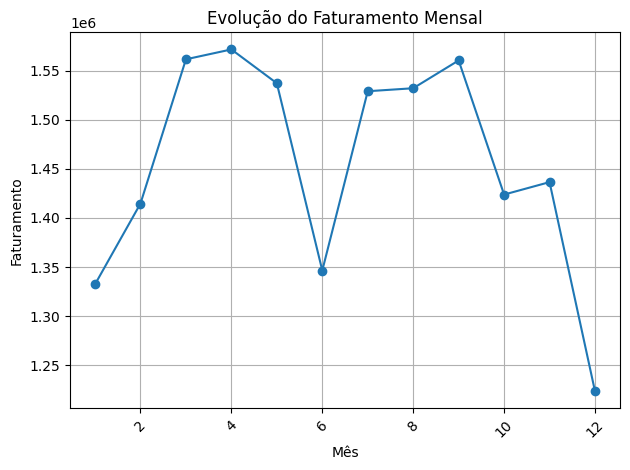

In [12]:
import matplotlib.pyplot as plt

# agrupar dados
mes = df.groupby("mes")["faturamento"].sum().sort_index()

# criar gráfico
plt.figure()
mes.plot(marker='o')

# título e rótulos
plt.title("Evolução do Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento")

# melhorar visual
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()

plt.show()

Criar coluna de mês

In [13]:
df["data_venda"]=df["data_venda"].astype(str).str.strip()
df["data_venda"]=pd.to_datetime(df["data_venda"],errors='coerce',
format="%Y-%m-%d"
)
df["mes"]=df["data_venda"].dt.to_period("M")

Exportar resultado

In [14]:
df.to_csv("resumo_vendas.csv",index=False)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        10000 non-null  int64         
 1   data_venda      10000 non-null  datetime64[ns]
 2   cliente         10000 non-null  object        
 3   produto         10000 non-null  object        
 4   categoria       10000 non-null  object        
 5   quantidade      10000 non-null  int64         
 6   preco_unitario  10000 non-null  float64       
 7   vendedor        10000 non-null  object        
 8   cidade          10000 non-null  object        
 9   estado          10000 non-null  object        
 10  faturamento     10000 non-null  float64       
 11  mes             10000 non-null  period[M]     
dtypes: datetime64[ns](1), float64(2), int64(2), object(6), period[M](1)
memory usage: 937.6+ KB


Faturamento por mês

In [16]:
df.groupby('mes')["faturamento"].sum().sort_values()

,faturamento
mes,
2024-12,1223728.66
2024-01,1332505.24
2024-06,1346568.09
2024-02,1414699.44
2024-10,1423821.79
2024-11,1436475.33
2024-07,1528937.90
2024-08,1531974.02
2024-05,1537043.09


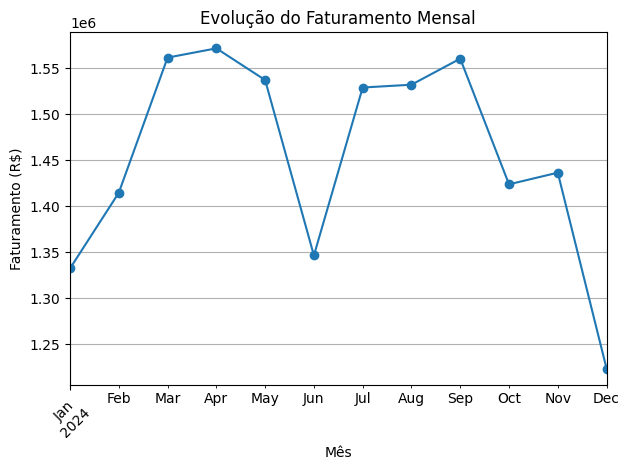

<Figure size 640x480 with 0 Axes>

In [17]:

import matplotlib.pyplot as plt

# agrupar dados
mes = df.groupby("mes")["faturamento"].sum().sort_index()

# criar gráfico
plt.figure()
mes.plot(marker='o', linestyle='-')

# título e rótulos
plt.title("Evolução do Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")

# melhorar visual
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()


#mes.plot(marker='o', linestyle='')

#plt.savefig("faturamento_mensal.png")

plt.show()
plt.savefig("faturamento_mensal.png")


#Observa-se uma tendência de crescimento ao longo dos meses.
#Há variações que podem indicar sazonalidade nas vendas.


In [18]:
df.groupby("categoria")["faturamento"].sum().sort_values(ascending=False)

,faturamento
categoria,
Eletrônicos,11741663.09
Móveis,4722771.51
Livros,544090.92
Acessórios,460376.91


In [19]:
df.groupby("cliente")["faturamento"].sum().sort_values(ascending=False).head(10)

,faturamento
cliente,
Mathias,122641.69
Asafe,121077.15
Lunna,111178.92
Carlos Eduardo,110931.92
Thiago,107474.24
Ravy,105380.55
Evelyn,103511.35
Alice,100859.35
José,100161.57


In [20]:
df["cliente"].value_counts().head(10)

,count
cliente,
Alexandre,50
Luan,49
Benício,49
Anna Liz,48
Arthur,48
Allana,48
Marina,48
Ravi,47
Hellena,47


#🚀 Projeto de Análise de vendas com SQL e Python
---
## 🎯 Objetivo
Analisar os dados de vendas com o objetivo de identificar padrões, gerar insights e propor recomendações estratégicas para o negócio.

---

## 🧩 Análises Realizadas

- 💰 Faturamento por produto  
- 🧾 Ticket médio por cliente  
- 🏙️ Vendas por cidade  
- 📈 Evolução mensal do faturamento  

---

## 📌 Principais Insights

- O produto **Notebook** se destaca como o maior faturamento, indicando alta demanda por itens de maior valor agregado.  
- A cidade de **Curitiba** apresenta o maior volume de vendas, evidenciando concentração de receita nessa região.  
- A categoria **Eletrônicos** lidera o faturamento, sendo o principal motor de receita do negócio.  
- A análise temporal mostra variações no faturamento ao longo dos meses, sugerindo possíveis padrões de sazonalidade.  

---

## 🚀 Recomendações

- 📢 Investir em campanhas e promoções para a categoria **Eletrônicos**  
- 📍 Desenvolver estratégias específicas para a cidade de **Curitiba**  
- 🔁 Criar ações de fidelização para clientes recorrentes  
- 📊 Monitorar a evolução mensal para identificar tendências e oportunidades  

---

## 🛠️ Ferramentas Utilizadas

- 🐘 PostgreSQL (SQL)
- 🐍 Python (Pandas)
- 📓 Google Colab

---
## Resultados das consultas SQL
Abaixo estão exemplos de consultas realizadas no postgreSQL e seus respectivos resultados:

## Cidade com maior faturamento
/content/cidade.png

## Produto mais vendido
/content/produto_mais_vendido.png

## Faturamento por produto(SQL)

/content/produtos.png

## Ticket Médio por Cliente(SQL)
A consulta abaixo foi utilizada para calcular o ticket médio por cliente, permitindo identificar padrões de consumo:

/content/Ticket_medio.png

## 📉Evolução do Faturamento ao longo do Tempo
O gráfico abaixo mostra a variação do faturamento ao longo dos meses, permitindo identificar tendências e possíveis sazonalidades.

![Faturamento mensal]

/content/faturamento_mensal.png

## 📎 Conclusão

Os dados analisados indicam que o desempenho da empresa está fortemente concentrado na categoria de eletrônicos e em regiões específicas. Com base nisso, é possível direcionar estratégias mais assertivas para maximizar resultados e explorar novas oportunidades de crescimento.


A análise do faturamento mensal evidencia a evolução das vendas ao longo do tempo, com variações que sugerem possíveis padrões de sazonalidade no comportamento dos clientes. Esses insights são fundamentais para apoiar o planejamento estratégico e a tomada de decisão, permitindo identificar oportunidades de crescimento e otimização de resultados.

Dessa forma, a empresa pode direcionar seus esforços para períodos de maior demanda e atuar estrategicamente em momentos de queda.